# Day 4 - Trees, Forests, SVMs & k-NN

## Introduction

In this notebook, I will train and compare four classification models on the same dataset:

- Decision Tree
- Random Forest
- Support Vector Machine (SVM)
- k-Nearest Neighbors (k-NN)

All models will use the same train/test split and the same evaluation metrics to make the comparison fair.

## Models Used

### Decision Tree
A Decision Tree makes predictions by asking a sequence of questions about the input features. It is easy to understand, but it may overfit if the tree becomes too deep.

### Random Forest
A Random Forest combines predictions from many decision trees. This usually makes it more stable and less likely to overfit than a single tree.

### Support Vector Machine
SVM tries to find the best boundary that separates the two classes with the largest possible margin.

### k-Nearest Neighbors
k-NN predicts a sample based on the classes of its closest training samples.

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

## Dataset

I used the Pima Indians Diabetes Dataset.

The target variable is `Outcome`:

- 0 means No Diabetes
- 1 means Diabetes

The same dataset and split used in Day 3 will be used again to ensure a fair model comparison.

In [56]:
df = pd.read_csv("diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [57]:
print("Dataset shape:", df.shape)
print()
df.info()


Dataset shape: (768, 9)

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [58]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

### Observation

The dataset contains eight numerical input features and one binary target column.

There are no missing values, so the dataset is ready for model training.

# Hands-On Lab: Model Comparison

## Step 1: Train a Decision Tree, Random Forest, SVM, and k-NN on the same train/test split from Day 3.

### Prepare Features and Target

The input features are stored in `X`, while the `Outcome` column is stored in `y`.

In [59]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

### Train/Test Split

The same train/test split from Day 3 is used for all four models.

Using the same split makes the comparison fair because every model is trained and tested on the same samples.

In [60]:
x_train,x_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X train shape:", x_train.shape)
print("X test shape:", x_test.shape)
print("y train shape:", y_train.shape)
print("y test shape:", y_test.shape)

X train shape: (614, 8)
X test shape: (154, 8)
y train shape: (614,)
y test shape: (154,)


### Create the Models

Four classification models are created using different decision-making methods.

In [61]:

models = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "SVM": SVC( kernel="rbf",
        
    ),

    "k-NN": KNeighborsClassifier(
     n_neighbors=5
    )
}


In [62]:
for name, model in models.items():
    model.fit(x_train, y_train)
    print(name, "trained successfully")

Decision Tree trained successfully
Random Forest trained successfully
SVM trained successfully
k-NN trained successfully


### Observation

All four classification models were successfully trained using the same training dataset.

Because the models use the same train/test split, their performance can be compared fairly.

## Step 2: Evaluate all four with the same metric ,and assemble the results into one comparison table.
Each model is evaluated using accuracy, precision, recall, and F1-score.
The F1-score will be used as the main metric for identifying the best-performing model.

In [63]:
result = []
for name,model in models.items():
 predictions = model.predict(x_test)
 accuracy = accuracy_score(y_test,predictions)
 precision= precision_score(y_test,predictions)
 recall = recall_score(y_test,predictions)
 f1 = f1_score(y_test,predictions)
 result.append({
    "model": name,
    "accuracy":accuracy ,
    "precision":precision,
    "Recall": recall,
    "F1":f1
 })
comparison_table = pd.DataFrame(result)

comparison_table

,model,accuracy,precision,Recall,F1
0,Decision Tree,0.792208,0.703704,0.703704,0.703704
1,Random Forest,0.759740,0.680851,0.592593,0.633663
2,SVM,0.720779,0.657143,0.425926,0.516854
3,k-NN,0.668831,0.530612,0.481481,0.504854


### Observation

The table compares all four models using the same test data and evaluation metrics.

The model with the highest F1 provides the best balance between precision and recall.

## Step 3: Random Forest Feature Importances

The Random Forest model provides a feature importance value for each input feature.

A higher importance value means that the feature had a greater role in the model's predictions.

In [64]:
random_forest = models["Random Forest"] # Get the Random Forest model

In [ ]:
#Create a DataFrame showing each feature and its importance
feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

feature_importance # Display the feature importance table

,Feature,Importance
0,Glucose,0.276009
1,BMI,0.159544
2,Age,0.127248
3,DiabetesPedigreeFunction,0.126731
4,BloodPressure,0.085606
5,Pregnancies,0.084456
6,Insulin,0.072409
7,SkinThickness,0.067997


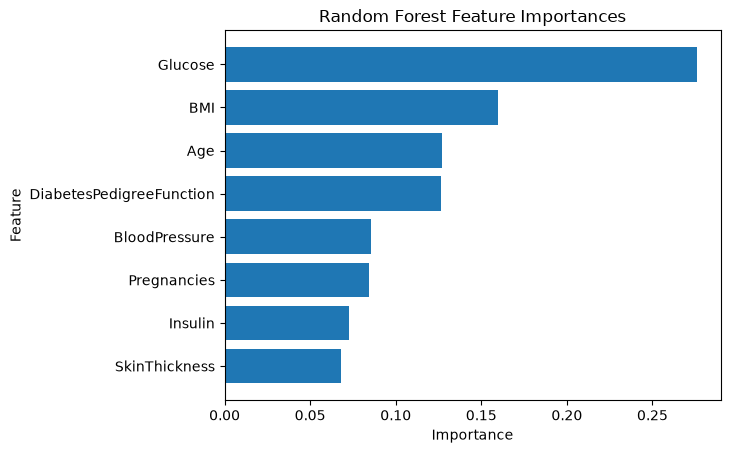

In [71]:
# Plot the importance of each feature
plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importances")

plt.gca().invert_yaxis() # Show the first feature at the top
plt.show()

### Observation

The Random Forest model shows that **Glucose** is the most important feature because it has the highest importance score.
SkinThickness has the lowest importance, which means it has the smallest effect on the model's predictions.

##  Step 4: Identify the best-performing model for this dataset and explain, in Markdown, why it likely won

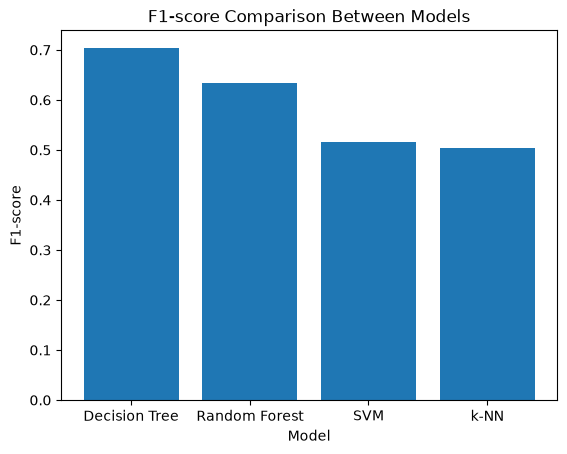

In [ ]:

plt.bar(
    comparison_table["model"],
    comparison_table["F1"]
)
plt.xlabel("Model")
plt.ylabel("F1-score")
plt.title("F1 ComParison Between Models")

plt.show()

### Observation

The Decision Tree gave the best result with an F1-score of **0.704**.

It also had the highest accuracy, precision, and recall.

It likely performed better because the tree rules matched the patterns in this dataset well, and limiting the depth helped prevent too much overfitting.